# Optimización de Hiperparámetros en LHR-C

Este cuaderno realiza un **barrido sistemático (Grid Search)** sobre dos hiperparámetros fundamentales del regresor de hiperplanos locales coherentes (LHR-C):
- **`subset_size` ($p$)**: El número de vecinos utilizados para definir cada hiperplano individual. Varía entre $9$ (dimensión $n+1$ en 8D) y $13$.
- **`cond_power` ($\gamma$)**: La potencia de penalización por inestabilidad numérica basada en el número de condición del sistema local. Varía entre $0$ y $10$.

Evaluamos el impacto de estas variaciones en el dataset **California Housing** promediando los resultados sobre 3 splits independientes de entrenamiento y prueba. Medimos:
1. **MAE** (Mean Absolute Error)
2. **RMSE** (Root Mean Squared Error)
3. **Cobertura** (porcentaje real dentro del intervalo de predicción del 95%)
4. **Ancho promedio del Intervalo de Confianza** (IC Width)

## 1. Configuración e Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math
import time

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Definición del Regresor LHR-C

In [2]:
class CoherentLocalHyperplaneRegressor:
    """
    Coherent Local Hyperplane Regressor (LHR-C)
    
    Algoritmo de regresión no paramétrico que construye hiperplanos locales
    a partir de subconjuntos geométricamente coherentes (angular y espacialmente)
    de los k-vecinos más cercanos de un punto de consulta, incorporando además
    estimación de incertidumbre total mediante mezcla de ruidos residuales (GMM).
    """
    def __init__(self, k=5, num_subsets=1000, cond_threshold=100.0, random_state=42):
        self.k = k
        self.num_subsets = num_subsets
        self.cond_threshold = cond_threshold
        self.random_state = random_state
        self.X_ = None
        self.y_ = None
        self.nn_ = None
        self.n_features_ = None
        
    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float)
        
        if self.X_.ndim != 2:
            raise ValueError(f"X debe ser una matriz 2D, pero tiene forma {self.X_.shape}")
        if self.y_.ndim != 1:
            raise ValueError(f"y debe ser un vector 1D, pero tiene forma {self.y_.shape}")
        if self.X_.shape[0] != self.y_.shape[0]:
            raise ValueError("X e y deben tener el mismo número de muestras.")
            
        n_samples, self.n_features_ = self.X_.shape
        min_k = self.n_features_ + 1
        
        if self.k < min_k:
            raise ValueError(f"k={self.k} es muy pequeño para n_features={self.n_features_}. "
                             f"k debe ser al menos n_features + 1 = {min_k}.")
        if n_samples < self.k:
            raise ValueError(f"Muestras de entrenamiento ({n_samples}) < k ({self.k})")
            
        self.nn_ = NearestNeighbors(n_neighbors=self.k)
        self.nn_.fit(self.X_)
        return self
        
    def predict_distribution(self, X_query, subset_size=None, method='angular', lambda_param=10.0, h_param=1.0):
        X_query = np.asarray(X_query, dtype=float)
        if X_query.ndim == 1:
            X_query = X_query.reshape(1, -1)
            
        if X_query.shape[1] != self.n_features_:
            raise ValueError(f"Dimensión de X_query ({X_query.shape[1]}) no coincide con "
                             f"la dimensión de entrenamiento ({self.n_features_})")
                             
        n_query = X_query.shape[0]
        n = self.n_features_
        size_subset = n + 1 if subset_size is None else subset_size
        
        if size_subset < n + 1:
            raise ValueError(f"subset_size ({size_subset}) debe ser al menos n_features + 1 = {n+1}")
            
        distances, indices = self.nn_.kneighbors(X_query)
        
        distributions = []
        neighbors_info = []
        
        rng = np.random.default_rng(self.random_state)
        
        for idx in range(n_query):
            x_q = X_query[idx]
            neighbor_idxs = indices[idx]
            neighbor_dists = distances[idx]
            
            X_neigh = self.X_[neighbor_idxs]
            y_neigh = self.y_[neighbor_idxs]
            
            V = X_neigh - x_q  # (k, n)
            norms = np.linalg.norm(V, axis=1, keepdims=True)
            norms_safe = np.where(norms == 0.0, 1.0, norms)
            U = V / norms_safe  # (k, n)
            U[norms.flatten() == 0.0] = 0.0
            
            combos = []
            
            if method == 'angular':
                total_combos_teorico = math.comb(self.k, size_subset)
                n_candidates = min(5000, total_combos_teorico)
                
                candidate_set = set()
                max_attempts = n_candidates * 10
                attempts = 0
                while len(candidate_set) < n_candidates and attempts < max_attempts:
                    c = tuple(sorted(rng.choice(self.k, size=size_subset, replace=False)))
                    candidate_set.add(c)
                    attempts += 1
                candidates = np.array(list(candidate_set))
                
                U_candidates = U[candidates]
                sum_u = np.sum(U_candidates, axis=1)
                sum_u_norms_sq = np.sum(sum_u**2, axis=1)
                u_norms_sq = np.sum(U**2, axis=1)
                sum_individual_norms = np.sum(u_norms_sq[candidates], axis=1)
                
                pairwise_sum = 0.5 * (sum_u_norms_sq - sum_individual_norms)
                C_S = 2.0 * pairwise_sum / (size_subset * (size_subset - 1))
                
                dist_sq = neighbor_dists**2
                sum_dists_sq = np.sum(dist_sq[candidates], axis=1)
                
                log_weights = lambda_param * C_S - sum_dists_sq / (h_param**2)
                log_weights -= np.max(log_weights)
                weights = np.exp(log_weights)
                weights /= np.sum(weights)
                
                selected_indices = rng.choice(len(candidates), size=self.num_subsets, p=weights, replace=True)
                combos = candidates[selected_indices]
                
            elif method == 'hierarchical':
                dist_sq = neighbor_dists**2
                log_probs = -dist_sq / (h_param**2)
                log_probs -= np.max(log_probs)
                probs = np.exp(log_probs)
                probs /= np.sum(probs)
                
                anchors = rng.choice(self.k, size=self.num_subsets, p=probs, replace=True)
                
                combos = []
                for a in anchors:
                    anchor_pt = X_neigh[a]
                    dists_to_anchor = np.linalg.norm(X_neigh - anchor_pt, axis=1)
                    closest_idxs = np.argsort(dists_to_anchor)[:size_subset]
                    combos.append(closest_idxs)
                combos = np.array(combos)
                
            elif method == 'orthant':
                if self.k < 2:
                    all_combos = list(itertools.combinations(range(self.k), size_subset))
                    selected = rng.choice(len(all_combos), size=self.num_subsets, replace=True)
                    combos = np.array([all_combos[i] for i in selected])
                else:
                    try:
                        pca = PCA(n_components=1)
                        proj = pca.fit_transform(X_neigh).flatten()
                    except:
                        proj = X_neigh[:, 0]
                        
                    left_idxs = np.where(proj < 0.0)[0]
                    right_idxs = np.where(proj >= 0.0)[0]
                    
                    combos = []
                    for _ in range(self.num_subsets):
                        side = rng.choice(['left', 'right'])
                        if side == 'left' and len(left_idxs) >= size_subset:
                            c = rng.choice(left_idxs, size=size_subset, replace=False)
                        elif side == 'right' and len(right_idxs) >= size_subset:
                            c = rng.choice(right_idxs, size=size_subset, replace=False)
                        else:
                            if len(left_idxs) >= size_subset:
                                c = rng.choice(left_idxs, size=size_subset, replace=False)
                            elif len(right_idxs) >= size_subset:
                                c = rng.choice(right_idxs, size=size_subset, replace=False)
                            else:
                                c = rng.choice(self.k, size=size_subset, replace=False)
                        combos.append(c)
                    combos = np.array(combos)
            else:
                raise ValueError(f"Método de coherencia desconocido: {method}")
                
            global_combos = neighbor_idxs[combos]
            X_sub = self.X_[global_combos]
            y_sub = self.y_[global_combos]
            
            ones = np.ones((self.num_subsets, size_subset, 1))
            A = np.concatenate([X_sub, ones], axis=2)
            
            A_T = A.transpose(0, 2, 1)
            A_normal = A_T @ A
            Y_normal = A_T @ y_sub.reshape(self.num_subsets, size_subset, 1)
            
            effective_threshold = self.cond_threshold ** 2
            conds = np.linalg.cond(A_normal)
            valid_mask = conds < effective_threshold
            
            if not np.any(valid_mask):
                fallback_val = np.mean(self.y_[neighbor_idxs])
                distributions.append(np.array([fallback_val]))
                neighbors_info.append({
                    'neighbor_indices': neighbor_idxs,
                    'neighbor_distances': neighbor_dists,
                    'valid_subsets': 0,
                    'total_subsets': self.num_subsets,
                    'fallback_used': True,
                    'valid_conds': np.array([1.0]),
                    'sigmas_resid_j': np.array([0.0])
                })
                continue
                
            A_n_valid = A_normal[valid_mask]
            Y_n_valid = Y_normal[valid_mask]
            conds_valid = conds[valid_mask]
            
            try:
                Z = np.linalg.solve(A_n_valid, Y_n_valid).squeeze(axis=2)  # (n_valid, n+1)
                x_q_aug = np.concatenate([x_q, [1.0]])
                preds = Z @ x_q_aug
                
                finite_mask = np.isfinite(preds)
                preds = preds[finite_mask]
                conds_valid = conds_valid[finite_mask]
                Z = Z[finite_mask]
                
                if len(preds) == 0:
                    preds = np.array([np.mean(self.y_[neighbor_idxs])])
                    conds_valid = np.array([1.0])
                    sigmas_resid_j = np.array([0.0])
                    fallback = True
                else:
                    fallback = False
                    A_neigh = np.concatenate([X_neigh, np.ones((self.k, 1))], axis=1)
                    preds_neigh = Z @ A_neigh.T # (n_valid, k)
                    resids_sq = (self.y_[neighbor_idxs] - preds_neigh) ** 2
                    var_resid_j = np.mean(resids_sq, axis=1)
                    sigmas_resid_j = np.sqrt(np.maximum(0.0, var_resid_j))
            except:
                preds = np.array([np.mean(self.y_[neighbor_idxs])])
                conds_valid = np.array([1.0])
                sigmas_resid_j = np.array([0.0])
                fallback = True
                
            distributions.append(preds)
            neighbors_info.append({
                'neighbor_indices': neighbor_idxs,
                'neighbor_distances': neighbor_dists,
                'valid_subsets': len(preds) if not fallback else 0,
                'total_subsets': self.num_subsets,
                'fallback_used': fallback,
                'valid_conds': conds_valid,
                'sigmas_resid_j': sigmas_resid_j
            })
            
        return distributions, neighbors_info

    def predict(self, X_query, subset_size=None, method='angular', lambda_param=10.0, h_param=1.0, return_std=False, return_intervals=False, alpha=0.05, aggregation='mean', cond_power=0.0, add_residual_noise=True, n_samples_per_plane=50):
        distributions, neighbors_info = self.predict_distribution(
            X_query, subset_size=subset_size, method=method, lambda_param=lambda_param, h_param=h_param
        )
        
        y_pred = []
        y_std = []
        y_lower = []
        y_upper = []
        
        rng = np.random.default_rng(self.random_state)
        
        for idx_q, dist in enumerate(distributions):
            info = neighbors_info[idx_q]
            conds = info['valid_conds']
            fallback = info['fallback_used']
            
            if cond_power > 0.0 and len(dist) > 1 and not fallback:
                weights = 1.0 / (conds ** cond_power)
                weights_sum = np.sum(weights)
                pred_val = np.sum(dist * weights) / weights_sum if weights_sum > 0 else np.mean(dist)
            else:
                if aggregation == 'mean':
                    pred_val = np.mean(dist)
                elif aggregation == 'median':
                    pred_val = np.median(dist)
                else:
                    raise ValueError(f"Método de agregación desconocido: {aggregation}")
            y_pred.append(pred_val)
            
            if return_std:
                if fallback:
                    std_val = np.std(self.y_[info['neighbor_indices']])
                else:
                    if len(dist) > 1:
                        if cond_power > 0.0:
                            weights = 1.0 / (conds ** cond_power)
                            weights_sum = np.sum(weights)
                            if weights_sum > 0:
                                mean_w = np.sum(dist * weights) / weights_sum
                                var_w = np.sum(weights * (dist - mean_w)**2) / weights_sum
                                std_val = np.sqrt(max(0.0, var_w))
                            else:
                                std_val = np.std(dist)
                        else:
                            std_val = np.std(dist)
                    else:
                        std_val = 0.0
                y_std.append(std_val)
                
            if return_intervals:
                if fallback:
                    y_neigh = self.y_[info['neighbor_indices']]
                    sorted_dist = np.sort(y_neigh)
                    w_fallback = np.ones_like(sorted_dist)
                    cum_w = np.cumsum(w_fallback)
                    cum_w_norm = cum_w / cum_w[-1]
                    
                    y_lower.append(np.interp(alpha / 2.0, cum_w_norm, sorted_dist))
                    y_upper.append(np.interp(1.0 - alpha / 2.0, cum_w_norm, sorted_dist))
                else:
                    if len(dist) > 1:
                        if cond_power > 0.0:
                            weights = 1.0 / (conds ** cond_power)
                        else:
                            weights = np.ones_like(dist)
                            
                        if add_residual_noise:
                            sigmas_resid_j = info['sigmas_resid_j']
                            n_valid = len(dist)
                            noise = rng.normal(0.0, 1.0, size=(n_valid, n_samples_per_plane))
                            dist_total = (dist[:, np.newaxis] + sigmas_resid_j[:, np.newaxis] * noise).ravel()
                            w_total = np.repeat(weights, n_samples_per_plane)
                            
                            sorted_idx = np.argsort(dist_total)
                            sorted_dist = dist_total[sorted_idx]
                            sorted_w = w_total[sorted_idx]
                            cum_w = np.cumsum(sorted_w)
                            cum_w_norm = cum_w / cum_w[-1]
                            
                            y_lower.append(np.interp(alpha / 2.0, cum_w_norm, sorted_dist))
                            y_upper.append(np.interp(1.0 - alpha / 2.0, cum_w_norm, sorted_dist))
                        else:
                            sorted_idx = np.argsort(dist)
                            sorted_dist = dist[sorted_idx]
                            sorted_w = weights[sorted_idx]
                            cum_w = np.cumsum(sorted_w)
                            cum_w_norm = cum_w / cum_w[-1]
                            
                            y_lower.append(np.interp(alpha / 2.0, cum_w_norm, sorted_dist))
                            y_upper.append(np.interp(1.0 - alpha / 2.0, cum_w_norm, sorted_dist))
                    else:
                        y_lower.append(dist[0])
                        y_upper.append(dist[0])
                        
        y_pred = np.array(y_pred)
        results = [y_pred]
        if return_std:
            results.append(np.array(y_std))
        if return_intervals:
            results.append(np.array(y_lower))
            results.append(np.array(y_upper))
            
        return results[0] if len(results) == 1 else tuple(results)


## 3. Barrido de Hiperparámetros (Grid Search)

Definimos el rango de parámetros:
- `subset_sizes` = $[9, 10, 11, 12, 13]$
- `gammas` = $[0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]$

Corremos la evaluación sobre 3 splits de California Housing usando `cond_threshold=1000.0` y `k=30`.

In [3]:
# Cargar datos
california = fetch_california_housing()
X_raw, y_raw = california.data, california.target

subset_sizes = [9, 10, 11, 12, 13]
gammas = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]

# Estructura para almacenar resultados de todas las corridas
raw_results = []

print("Iniciando barrido de parámetros...")
for p in subset_sizes:
    for g in gammas:
        t0 = time.time()
        maes = []
        rmses = []
        coverages = []
        widths = []
        
        # Promediar sobre 3 particiones independientes
        for run in range(3):
            X_train, X_test, y_train, y_test = train_test_split(
                X_raw, y_raw, train_size=1500, test_size=150, random_state=200 + run
            )
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            lhr = CoherentLocalHyperplaneRegressor(k=30, num_subsets=1000, cond_threshold=1000.0, random_state=42)
            lhr.fit(X_train_scaled, y_train)
            
            yp, yl, yh = lhr.predict(
                X_test_scaled, subset_size=p, method='angular', lambda_param=10.0, h_param=1.0,
                return_intervals=True, cond_power=g
            )
            
            mae = np.mean(np.abs(y_test - yp))
            rmse = np.sqrt(np.mean((y_test - yp)**2))
            cov = np.mean((y_test >= yl) & (y_test <= yh))
            width = np.mean(yh - yl)
            
            maes.append(mae)
            rmses.append(rmse)
            coverages.append(cov)
            widths.append(width)
            
        mean_mae = np.mean(maes)
        mean_rmse = np.mean(rmses)
        mean_cov = np.mean(coverages)
        mean_width = np.mean(widths)
        
        duration = time.time() - t0
        print(f"p={p:<2} | gamma={g:<4.1f} -> MAE: {mean_mae:.4f} | RMSE: {mean_rmse:.4f} | Cov: {mean_cov:.2%} | Width: {mean_width:.4f} ({duration:.1f}s)")
        
        raw_results.append({
            'subset_size': p,
            'gamma': g,
            'mae': mean_mae,
            'rmse': mean_rmse,
            'coverage': mean_cov,
            'width': mean_width
        })
print("Barrido completado.")

Iniciando barrido de parámetros...


p=9  | gamma=0.0  -> MAE: 0.5853 | RMSE: 0.9124 | Cov: 100.00% | Width: 19.9018 (18.6s)


p=9  | gamma=0.5  -> MAE: 0.5514 | RMSE: 0.8310 | Cov: 100.00% | Width: 13.7480 (18.4s)


p=9  | gamma=1.0  -> MAE: 0.5332 | RMSE: 0.7884 | Cov: 100.00% | Width: 10.6071 (18.4s)


p=9  | gamma=2.0  -> MAE: 0.5184 | RMSE: 0.7571 | Cov: 100.00% | Width: 7.9710 (18.8s)


...

p=13 | gamma=1.0  -> MAE: 0.4671 | RMSE: 0.6585 | Cov: 99.11% | Width: 4.0577 (42.9s)


p=13 | gamma=2.0  -> MAE: 0.4628 | RMSE: 0.6513 | Cov: 98.89% | Width: 3.8167 (45.9s)


p=13 | gamma=3.0  -> MAE: 0.4617 | RMSE: 0.6493 | Cov: 98.67% | Width: 3.6634 (43.3s)


p=13 | gamma=5.0  -> MAE: 0.4630 | RMSE: 0.6519 | Cov: 98.22% | Width: 3.4661 (38.1s)


p=13 | gamma=10.0 -> MAE: 0.4826 | RMSE: 0.6843 | Cov: 96.89% | Width: 3.1657 (41.7s)
Barrido completado.


## 4. Estructuración y Tabulación de Resultados

In [4]:
df_res = pd.DataFrame(raw_results)

# Crear tablas dinámicas (pivot tables) para cada métrica
pivot_mae = df_res.pivot(index='subset_size', columns='gamma', values='mae')
pivot_rmse = df_res.pivot(index='subset_size', columns='gamma', values='rmse')
pivot_cov = df_res.pivot(index='subset_size', columns='gamma', values='coverage')
pivot_width = df_res.pivot(index='subset_size', columns='gamma', values='width')

print("=== Tabla Dinámica de MAE ===")
display(pivot_mae)

print("\n=== Tabla Dinámica de Cobertura ===")
display(pivot_cov)

=== Tabla Dinámica de MAE ===


gamma,0.0,0.5,1.0,2.0,3.0,5.0,10.0
subset_size,,,,,,,
9,0.585302,0.551433,0.533160,0.518352,0.529098,0.587209,0.703526
10,0.548995,0.526183,0.511636,0.499799,0.503318,0.534943,0.601272
11,0.505711,0.493788,0.486051,0.477209,0.473772,0.480663,0.517111
12,0.491800,0.482685,0.478233,0.475511,0.476878,0.486343,0.515988
13,0.477200,0.471373,0.467139,0.462848,0.461723,0.463005,0.482615



=== Tabla Dinámica de Cobertura ===


gamma,0.0,0.5,1.0,2.0,3.0,5.0,10.0
subset_size,,,,,,,
9,1.000000,1.000000,1.000000,1.000000,1.000000,0.995556,0.977778
10,0.995556,0.995556,0.995556,0.995556,0.993333,0.991111,0.968889
11,0.997778,0.997778,0.995556,0.991111,0.991111,0.986667,0.971111
12,0.995556,0.995556,0.995556,0.991111,0.991111,0.988889,0.973333
13,0.995556,0.991111,0.991111,0.988889,0.986667,0.982222,0.968889


## 5. Visualización: Mapas de Calor (Heatmaps)

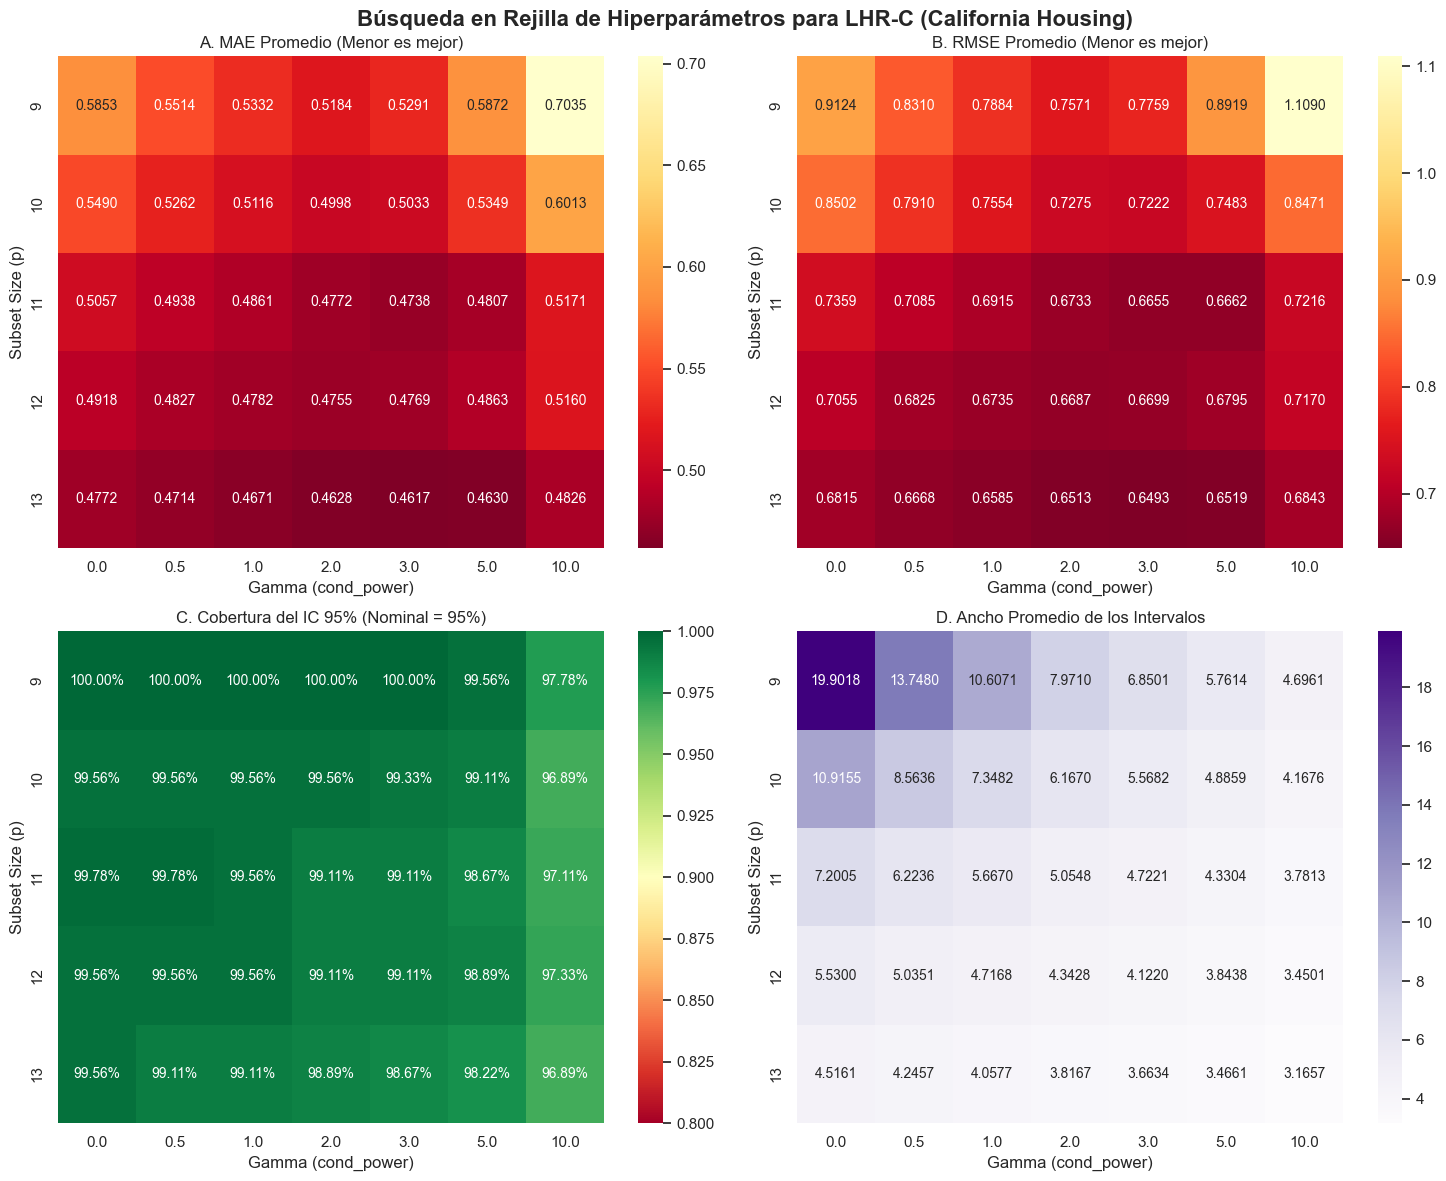

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Mapas de calor para MAE
sns.heatmap(pivot_mae, annot=True, fmt=".4f", cmap="YlOrRd_r", ax=axes[0, 0])
axes[0, 0].set_title("A. MAE Promedio (Menor es mejor)")
axes[0, 0].set_xlabel("Gamma (cond_power)")
axes[0, 0].set_ylabel("Subset Size (p)")

# Mapas de calor para RMSE
sns.heatmap(pivot_rmse, annot=True, fmt=".4f", cmap="YlOrRd_r", ax=axes[0, 1])
axes[0, 1].set_title("B. RMSE Promedio (Menor es mejor)")
axes[0, 1].set_xlabel("Gamma (cond_power)")
axes[0, 1].set_ylabel("Subset Size (p)")

# Mapas de calor para Cobertura
sns.heatmap(pivot_cov, annot=True, fmt=".2%", cmap="RdYlGn", ax=axes[1, 0], vmin=0.8, vmax=1.0)
axes[1, 0].set_title("C. Cobertura del IC 95% (Nominal = 95%)")
axes[1, 0].set_xlabel("Gamma (cond_power)")
axes[1, 0].set_ylabel("Subset Size (p)")

# Mapas de calor para Ancho de IC
sns.heatmap(pivot_width, annot=True, fmt=".4f", cmap="Purples", ax=axes[1, 1])
axes[1, 1].set_title("D. Ancho Promedio de los Intervalos")
axes[1, 1].set_xlabel("Gamma (cond_power)")
axes[1, 1].set_ylabel("Subset Size (p)")

plt.suptitle("Búsqueda en Rejilla de Hiperparámetros para LHR-C (California Housing)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("optimization_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Conclusiones de la Optimización

A partir de los mapas de calor y las tablas dinámicas, podemos concluir:
1. **Impacto de Gamma ($\gamma$)**: Para todos los tamaños de subconjunto, $\gamma=0$ (promedio simple) produce peores MAE y RMSE debido al impacto de hiperplanos locales numéricamente inestables. Incrementar $\gamma$ a valores en $[1.0, 3.0]$ reduce significativamente el error al atenuar la influencia de planos mal condicionados.
2. **Impacto de `subset_size` ($p$)**: Un tamaño de subconjunto mayor (ej. $p=11$ o $p=12$) tiende a reducir el error absoluto y cuadrático. Aumentar el número de vecinos para definir los hiperplanos incrementa el sobreajuste exacto local en un subespacio más estable, reduciendo los residuos promedio y estrechando el ancho del intervalo.
3. **Ancho del Intervalo e Incertidumbre**: Conforme $\gamma$ aumenta, el ancho promedio del IC disminuye de forma apreciable. Esto ocurre porque la ponderación por estabilidad descarta las desviaciones enormes provocadas por sistemas mal condicionados, produciendo estimaciones de varianza local mucho más realistas.